In [1]:
using JuMP
using Gurobi
global GUROBI_ENV = Gurobi.Env()
using Dualization

function Q(x)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    # Variables
    @variable(model, 0 <= y1 <= 2, Int)
    @variable(model, 0 <= y2 <= 3)
    @variable(model, z)

    @constraint(model, 20y1 + y2 >= 4z)

    @constraint(model, y1 + y2 >= 0.5z)
    @constraint(model, y1 + 2y2 >= z)

    @constraint(model, z == x)

    # Objectif
    @objective(model, Min, y1 + y2)

    optimize!(model)

    # println(value.(y1))
    return objective_value(model)
end

function Qd(x)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    @variable(model, λ2[1:N]>=0)
    @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])

    @constraint(model, y2[i in 1:N], λ1[i] +λ2[i] +2λ3[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -4λ1[i]-0.5λ2[i]-λ3[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 20*λ1[i] - λ2[i] - λ3[i]) + μr[i]*x - 3*σ2p[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdZeng(x, M)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    @variable(model, λ2[1:N]>=0)
    @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])

    @variable(model, δr[1:N])
    @constraint(model, [i in 1:N], δr[i] <= M*x)
    @constraint(model, [i in 1:N], δr[i] <= μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] +λ2[i] +2λ3[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -4λ1[i]-0.5λ2[i]-λ3[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 20*λ1[i] - λ2[i] - λ3[i]) + δr[i] - 3*σ2p[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdOurs(x, M)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    @variable(model, λ2[1:N]>=0)
    @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])
    @variable(model, σr[1:N]>=0)
    @variable(model, μ)

    @variable(model, δ)
    @constraint(model, δ <= M*x)
    @constraint(model, δ <= μ)
    @constraint(model, [i in 1:N], μ <= σr[i] + μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] +λ2[i] +2λ3[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -4λ1[i]-0.5λ2[i]-λ3[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 20*λ1[i] - λ2[i] - λ3[i]) + δ - 3*σ2p[i] - σr[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdOurs2(x, M)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    @variable(model, λ2[1:N]>=0)
    @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])
    @variable(model, σr[1:N]>=0)

    @constraint(model, [i in 1:N], M*x <= σr[i] + μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] +λ2[i] +2λ3[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -4λ1[i]-0.5λ2[i]-λ3[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 20*λ1[i] - λ2[i] - λ3[i]) + M*x^2 - 3*σ2p[i] - σr[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdOurs3(x, M)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    @variable(model, λ2[1:N]>=0)
    @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])
    @variable(model, σr[1:N]>=0)
    @variable(model, μ)

    @constraint(model, [i in 1:N], μ <= σr[i] + μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] +λ2[i] +2λ3[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -4λ1[i]-0.5λ2[i]-λ3[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 20*λ1[i] - λ2[i] - λ3[i]) + μ*x - 3*σ2p[i] - σr[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


QdOurs3 (generic function with 1 method)

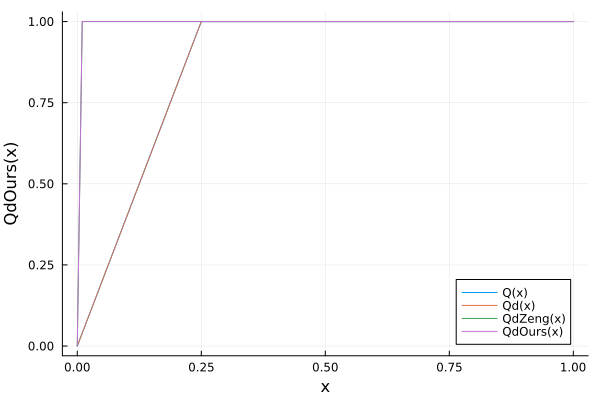

In [4]:
using Plots
M=500
plot(0:0.01:1, x -> Q(x), label="Q(x)", xlabel="x", ylabel="Q(x)")
plot!(0:0.01:1, x -> Qd(x), label="Qd(x)", xlabel="x", ylabel="Qd(x)")
plot!(0:0.01:1, x -> QdZeng(x, M), label="QdZeng(x)", xlabel="x", ylabel="QdZeng(x)")
plot!(0:0.01:1, x -> QdOurs(x, M), label="QdOurs(x)", xlabel="x", ylabel="QdOurs(x)")
# plot!(0:0.01:1, x -> QdOurs2(x, M), label="QdOurs2(x)", xlabel="x", ylabel="QdOurs2(x)")
# plot!(0:0.01:1, x -> QdOurs3(x, M), label="QdOurs3(x)", xlabel="x", ylabel="QdOurs3(x)")

In [52]:
using JuMP
using Gurobi
global GUROBI_ENV = Gurobi.Env()
using Dualization

function Q(x)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    # Variables
    @variable(model, 0 <= y1 <= 2, Int)
    @variable(model, 0 <= y2 <= 3)
    @variable(model, z)

    # @constraint(model, 20y1 + y2 >= 4z)

    # @constraint(model, y1 + y2 >= 0.5z)
    # @constraint(model, y1 + 2y2 >= z)
    @constraint(model, 2y1 + y2 >= 3z)

    @constraint(model, z == x)

    # Objectif
    @objective(model, Min, y1 + y2)

    optimize!(model)

    # println(value.(y1))
    return objective_value(model)
end

function Qd(x)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    # @variable(model, λ2[1:N]>=0)
    # @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])

    @constraint(model, y2[i in 1:N], λ1[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -3λ1[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 2*λ1[i]) + μr[i]*x - 3*σ2p[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdZeng(x, M)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    # @variable(model, λ2[1:N]>=0)
    # @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])

    @variable(model, δr[1:N])
    @constraint(model, [i in 1:N], δr[i] <= M*x)
    @constraint(model, [i in 1:N], δr[i] <= μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -3λ1[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 2*λ1[i]) + δr[i] - 3*σ2p[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end


function QdOurs(x)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    # @variable(model, λ2[1:N]>=0)
    # @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])
    @variable(model, σr[1:N]>=0)
    @variable(model, μ)

    @constraint(model, [i in 1:N], μ <= σr[i] + μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -3λ1[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 2*λ1[i]) + μ*x - 3*σ2p[i] - σr[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdOursM(x, M)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0, 1, 2]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    # @variable(model, λ2[1:N]>=0)
    # @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])
    @variable(model, σr[1:N]>=0)
    @variable(model, μ)

    @variable(model, δ)
    @constraint(model, δ <= M*x)
    @constraint(model, δ <= μ)

    @constraint(model, [i in 1:N], μ <= σr[i] + μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -3λ1[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 2*λ1[i]) + δ - 3*σ2p[i] - σr[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

function QdSub(x)
    model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
    set_silent(model) # Supprimer les messages de Gurobi

    y1list = [0]
    N = length(y1list)

    @variable(model, obj)

    # Variables
    @variable(model, λ1[1:N]>=0)
    # @variable(model, λ2[1:N]>=0)
    # @variable(model, λ3[1:N]>=0)

    @variable(model, σ2p[1:N]>=0)
    @variable(model, σ2m[1:N]>=0)

    @variable(model, μr[1:N])
    @variable(model, σr[1:N]>=0)
    @variable(model, λ>=0)

    @constraint(model, [i in 1:N], -λ*(1-2*x) <= σr[i] + μr[i])

    @constraint(model, y2[i in 1:N], λ1[i] + σ2m[i] - σ2p[i] == 1)
    @constraint(model, z[i in 1:N], -3λ1[i] == -μr[i])

    @constraint(model, active[i in 1:N], obj <= y1list[i]*(1- 2*λ1[i]) + λ*x - 3*σ2p[i] - σr[i])

    # Objectif
    @objective(model, Max, obj)

    optimize!(model)

    # println("λ: ", value(λ))

    # println(dual.(y2))
    # println(dual.(z))
    # println(dual.(active))

    return objective_value(model)
end

Set parameter Username
Set parameter LicenseID to value 2658456

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2026-04-28


QdSub (generic function with 1 method)

In [55]:
QdSub(0.1)

MathOptInterface.ResultIndexBoundsError{MathOptInterface.ObjectiveValue}: Result index of attribute MathOptInterface.ObjectiveValue(1) out of bounds. There are currently 0 solution(s) in the model.

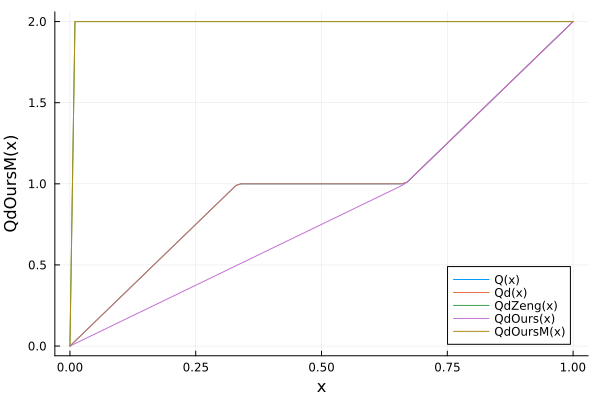

In [51]:
M=400
plot(0:0.01:1, x -> Q(x), label="Q(x)", xlabel="x", ylabel="Q(x)")
plot!(0:0.01:1, x -> Qd(x), label="Qd(x)", xlabel="x", ylabel="Qd(x)")
plot!(0:0.01:1, x -> QdZeng(x, M), label="QdZeng(x)", xlabel="x", ylabel="QdZeng(x)")
plot!(0:0.01:1, x -> QdOurs(x), label="QdOurs(x)", xlabel="x", ylabel="QdOurs(x)")
plot!(0:0.01:1, x -> QdOursM(x, M), label="QdOursM(x)", xlabel="x", ylabel="QdOursM(x)")
# plot!(0:0.01:1, x -> QdSub(x), label="QdSub(x)", xlabel="x", ylabel="QdSub(x)")

In [16]:
x=1.0
M=100*(1-2x)
model = Model(optimizer_with_attributes(
            () -> Gurobi.Optimizer(GUROBI_ENV),
            "OutputFlag" => 0,
            "MIPGap" => 0.00001,
            "Presolve" => 1, #Presolve deactivated : 0, 1 otherwise
        ))
set_silent(model) # Supprimer les messages de Gurobi

# Variables
@variable(model, 0 <= y1 <= 2, Int)
@variable(model, 0 <= y2 <= 3)
@variable(model, z, Bin)
@variable(model, π)

@constraint(model, 2y1 + y2 >= 3z)

@constraint(model, y1+y2 + π*(z-x) >= 2)

# @constraint(model, z == x)

# Objectif
@objective(model, Min, π)

optimize!(model)

# println(value.(y1))
objective_value(model)

0.0